<a href="https://colab.research.google.com/github/ViniciusCardoso7/Bootcamp-Data-DIO-Python-Projeto-Final.2/blob/main/deteccao_fraude_credit_card.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deteccao_Fraude

1.Carregando as bibliotecas:


In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
    roc_auc_score,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score
)

Para o XGBoost e o SHAP:


In [32]:
from xgboost import XGBClassifier
import shap

Carregando o dataset:


In [33]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "creditcard.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "mlg-ulb/creditcardfraud",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)
print("5 primeiros registros:", df.head())

/tmp/ipykernel_2314/2146012577.py:8: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'creditcardfraud' dataset.
5 primeiros registros:    Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.81773

Primeira inspeção:

In [34]:
df.shape
df.info()
df.isna().sum().sum()
df["Class"].value_counts()
df["Class"].value_counts(normalize=True) * 100
#O objetivo é mostrar explicitamente a proporção das classes. Nesse conjunto, existem 492 fraudes em 284.807 registros, o que representa aproximadamente 0,17% dos dados.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

,proportion
Class,
0,99.827251
1,0.172749


**Por que a acurácia engana?**

In [35]:
total = len(df)
fraudes = df["Class"].sum()
normais = total - fraudes

acuracia_modelo1= normais / total
acuracia_modelo1

np.float64(0.9982725143693799)

Um classificador que sempre responde 0 pode obter aproximadamente 99,8% de acurácia, mas terá:

* Recall da fraude: 0
* Precisçao de fraude : Indefinida ou 0
* F1 da fraude:0

Isso acontece porque a acurácia mede o total de acertos, enquanto o problema está justamente em encontrar a classe rara.
* Recall: entre todas as fraudes reais, quantas foram encontradas.
* Precisão: entre todas as transações marcadas como fraude, quantas realmente eram fraude.
* F1: equilíbrio entre precisão e recall.

ROC-AUC: capacidade de ordenar as classes em diferentes limiares.

PR-AUC: geralmente mais informativa em problemas com classe positiva muito rara.

Para fraude, use o recall da classe 1 como métrica principal, mas não ignore a precisão. Um recall alto pode gerar uma quantidade impraticável de falsos positivos.


Comparando desempenho dos modelos usando Gráfico de barras.

2.Preparação dos dados:

Novas variáveis:

A coluna "Amount" tem uma distribuição altamente assimétrica, com a maioria das transações concentradas em valores baixos e algumas transações de valores muito altos. Para lidar com isso, aplicamos a transformação logarítmica para reduzir o impacto dos valores extremos e melhorar a performance do modelo

In [30]:
df["LogAmount"] = np.log1p(df["Amount"])

Retirando a coluna "Amount" do conjunto de features, pois agora temos a versão transformada "LogAmount". A coluna "Class" é a variável alvo e não deve ser incluída nas features.

In [41]:
features = [col for col in df.columns if col not in ["Class", "Amount"]]

X = df[features]
y = df["Class"]

Separando os dados utilizando stretify (Em treino e teste):




In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

O stratify=y garante que a proporção de fraudes permaneça semelhante nos conjuntos de treino e teste.

Escalanomento:
O escalonamento deve ser feito dentro de um Pipeline, evitando vazamento de dados.

In [ ]:
scaler = StandardScaler()


3.Modelos:

Regressão Logistíca:

In [ ]:
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ))
])

logistic_model.fit(X_train, y_train)

proba_logistic = logistic_model.predict_proba(X_test)[:, 1]
pred_logistic = (proba_logistic >= 0.5).astype(int)

O parâmetro class_weight="balanced" aumenta a importância da classe minoritária durante o treinamento.

Random Forest:

In [28]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

proba_rf = rf_model.predict_proba(X_test)[:, 1]
pred_rf = (proba_rf >= 0.5).astype(int)

Como o Random Forest não depende da mesma forma da escala das variáveis, ele pode ser treinado sem StandardScaler.

XGBoost:

In [ ]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
scale_pos_weight

np.float64(577.2868020304569)

In [46]:
xgb_model = XGBClassifier(
    n_estimators=300,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1
)

# Ensure X_train and X_test have unique column names before fitting
X_train = X_train.loc[:, ~X_train.columns.duplicated()]
X_test = X_test.loc[:, ~X_test.columns.duplicated()]

xgb_model.fit(X_train, y_train)

proba_xgb = xgb_model.predict_proba(X_test)[:, 1]
pred_xgb = (proba_xgb >= 0.5).astype(int)

As variáveis de predição disponíveis no ambiente são:

In [40]:
print('proba_logistic:')
display(proba_logistic)
print('\npred_logistic:')
display(pred_logistic)
print('\nproba_rf:')
display(proba_rf)
print('\npred_rf:')
display(pred_rf)
print('\nproba_xgb:')
display(proba_xgb)
print('\npred_xgb:')
display(pred_xgb)

proba_logistic:


array([0.00771669, 0.05933312, 0.00029405, ..., 0.00018508, 0.00345928,
       0.09213815])


pred_logistic:


array([0, 0, 0, ..., 0, 0, 0])


proba_rf:


array([0., 0., 0., ..., 0., 0., 0.])


pred_rf:


array([0, 0, 0, ..., 0, 0, 0])


proba_xgb:


NameError: name 'proba_xgb' is not defined

Proporção entre classes

In [ ]:
model_names = resultados['modelo']
precision = resultados['precision_fraud']
recall = resultados['recall_fraud']
f1 = resultados['f1_fraud']

x = np.arange(len(model_names))
width = 0.2

fig, ax = plt.subplots(figsize=(12, 7))

rects1 = ax.bar(x - width, precision, width, label='Precisão')
rects2 = ax.bar(x, recall, width, label='Recall')
rects3 = ax.bar(x + width, f1, width, label='F1-Score')

ax.set_xlabel('Modelo')
ax.set_ylabel('Score')
ax.set_title('Comparação de Desempenho dos Modelos (Fraude)')
ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

plt.tight_layout()
plt.show()

4.Avaliação:

In [ ]:
def avaliar_modelo(nome, y_true, probabilidades, threshold=0.5):
    predicoes = (probabilidades >= threshold).astype(int)

    return {
        "modelo": nome,
        "limiar": threshold,
        "precision_fraud": precision_score(
            y_true, predicoes, zero_division=0
        ),
        "recall_fraud": recall_score(
            y_true, predicoes, zero_division=0
        ),
        "f1_fraud": f1_score(
            y_true, predicoes, zero_division=0
        ),
        "roc_auc": roc_auc_score(y_true, probabilidades),
        "pr_auc": average_precision_score(y_true, probabilidades)
    }

5.Comparando Modelos:

In [ ]:
resultados = pd.DataFrame([
    avaliar_modelo("Regressão Logística", y_test, proba_logistic),
    avaliar_modelo("Random Forest", y_test, proba_rf),
    avaliar_modelo("XGBoost", y_test, proba_xgb)
])

resultados.sort_values("recall_fraud", ascending=False)

relatório detalhado do modelo escolhido:

In [47]:
print(classification_report(
    y_test,
    (proba_xgb >= 0.5).astype(int),
    target_names=["Normal", "Fraude"],
    zero_division=0
))

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
      Fraude       0.88      0.84      0.86        98

    accuracy                           1.00     56962
   macro avg       0.94      0.92      0.93     56962
weighted avg       1.00      1.00      1.00     56962



*Matriz de confusão*

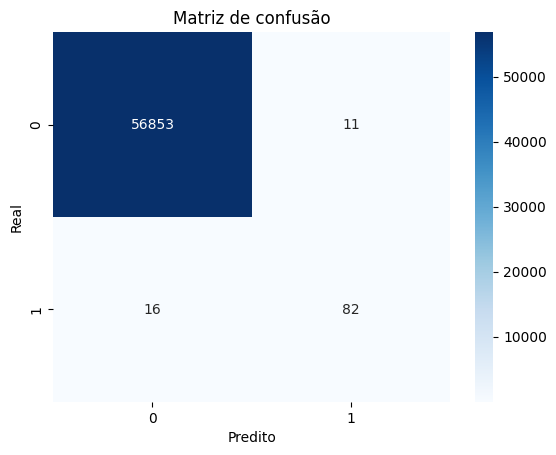

In [48]:
cm = confusion_matrix(
    y_test,
    (proba_xgb >= 0.5).astype(int)
)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.title("Matriz de confusão")
plt.show()

Ajuste do limiar de decisão.
O limiar padrão de 0,5 não precisa ser o melhor para fraude. Um limiar menor normalmente aumenta o recall, mas também pode aumentar os falsos positivos.

In [49]:
thresholds = np.arange(0.05, 0.96, 0.05)

In [50]:
threshold_results = []

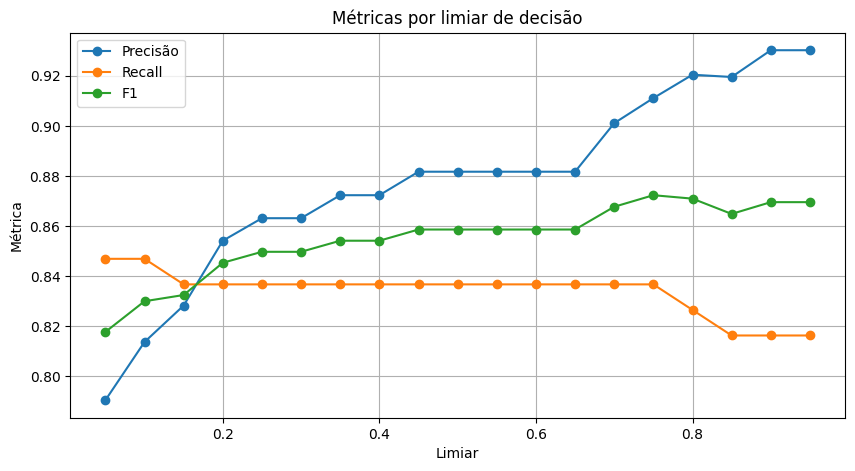

In [51]:
for threshold in thresholds:
    predictions = (proba_xgb >= threshold).astype(int)

    threshold_results.append({
        "threshold": threshold,
        "precision": precision_score(
            y_test, predictions, zero_division=0
        ),
        "recall": recall_score(
            y_test, predictions, zero_division=0
        ),
        "f1": f1_score(
            y_test, predictions, zero_division=0
        )
    })

threshold_df = pd.DataFrame(threshold_results)
threshold_df

plt.figure(figsize=(10, 5))

plt.plot(
    threshold_df["threshold"],
    threshold_df["precision"],
    marker="o",
    label="Precisão"
)

plt.plot(
    threshold_df["threshold"],
    threshold_df["recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["threshold"],
    threshold_df["f1"],
    marker="o",
    label="F1"
)

plt.xlabel("Limiar")
plt.ylabel("Métrica")
plt.title("Métricas por limiar de decisão")
plt.legend()
plt.grid()
plt.show()

maximizar o F1:

In [52]:
best_threshold = threshold_df.loc[
    threshold_df["f1"].idxmax(),
    "threshold"
]

best_threshold

np.float64(0.7500000000000001)

Curvas ROC e precisão-recall:

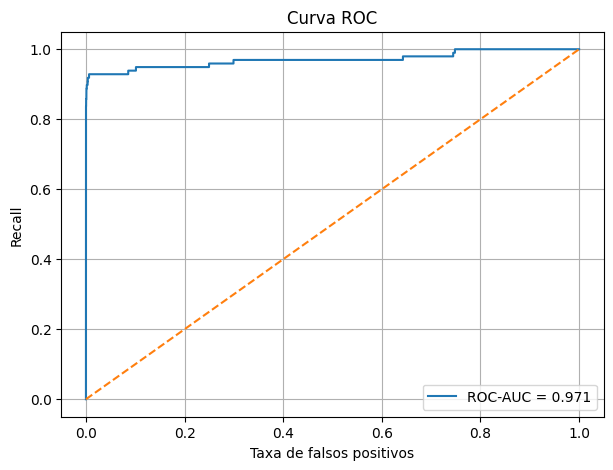

In [53]:
fpr, tpr, _ = roc_curve(y_test, proba_xgb)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc_score(y_test, proba_xgb):.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("Taxa de falsos positivos")
plt.ylabel("Recall")
plt.title("Curva ROC")
plt.legend()
plt.grid()
plt.show()

curva de precisão e recall:

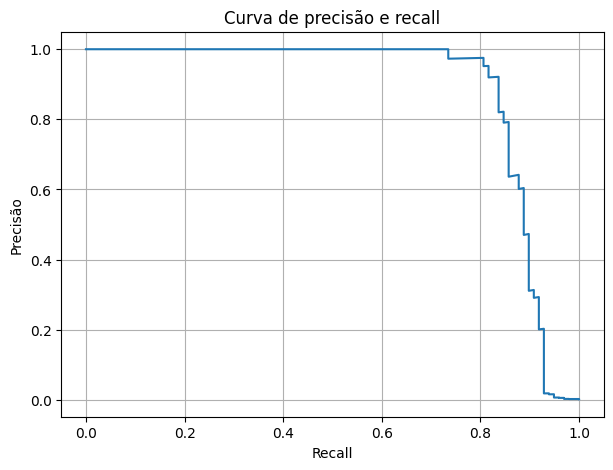

In [54]:
precision, recall, _ = precision_recall_curve(y_test, proba_xgb)

plt.figure(figsize=(7, 5))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precisão")
plt.title("Curva de precisão e recall")
plt.grid()
plt.show()


Undersampling e oversampling:

In [55]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

In [63]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import NearMiss

### Oversampling com SMOTE
SMOTE gera amostras sintéticas da classe minoritária, em vez de simplesmente duplicá-las, o que pode levar a um modelo mais robusto.

In [64]:
smote_pipeline = ImbPipeline([
    ("scaler", StandardScaler()),
    ("sampler", SMOTE(random_state=42)),
    ("model", LogisticRegression(max_iter=1000))
])

smote_pipeline.fit(X_train, y_train)
proba_smote = smote_pipeline.predict_proba(X_test)[:, 1]


### Undersampling com NearMiss
NearMiss seleciona amostras da classe majoritária com base na sua proximidade com as amostras da classe minoritária, o que pode ajudar o modelo a focar nas regiões de fronteira.

In [68]:
nearmiss_pipeline = ImbPipeline([
    ("scaler", StandardScaler()),
    ("sampler", NearMiss(version=1, n_neighbors=3)),
    ("model", LogisticRegression(max_iter=1000))
])

nearmiss_pipeline.fit(X_train, y_train)
proba_nearmiss = nearmiss_pipeline.predict_proba(X_test)[:, 1]

### Comparando os resultados com SMOTE e NearMiss

In [67]:
pd.DataFrame([
    avaliar_modelo("SMOTE", y_test, proba_smote),
    avaliar_modelo("NearMiss", y_test, proba_nearmiss)
])

,modelo,limiar,precision_fraud,recall_fraud,f1_fraud,roc_auc,pr_auc
0,SMOTE,0.5,0.058102,0.918367,0.109290,0.970966,0.721528
1,NearMiss,0.5,0.004019,0.959184,0.008005,0.942822,0.208816


### Curvas Precision-Recall para SMOTE e NearMiss

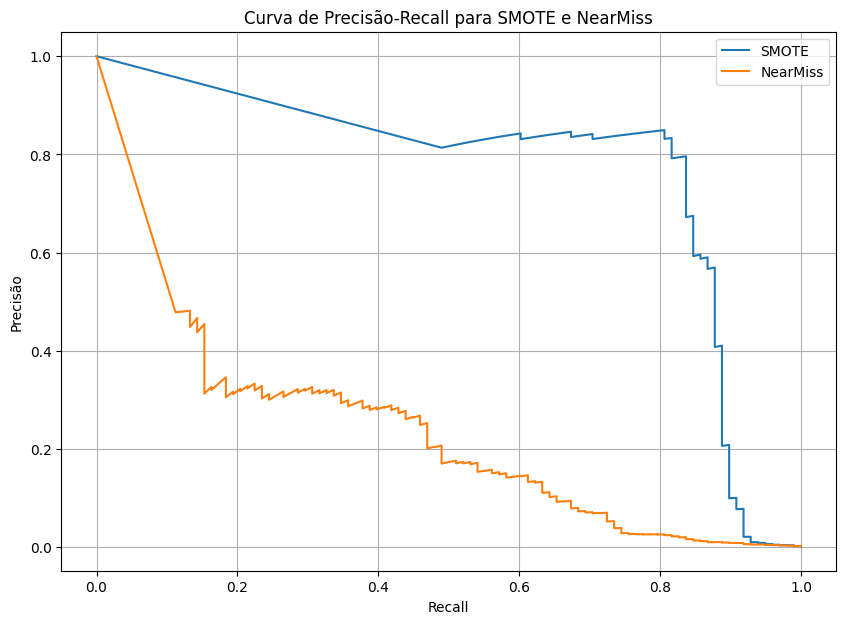

In [69]:
precision_smote, recall_smote, _ = precision_recall_curve(y_test, proba_smote)
precision_nearmiss, recall_nearmiss, _ = precision_recall_curve(y_test, proba_nearmiss)

plt.figure(figsize=(10, 7))
plt.plot(recall_smote, precision_smote, label='SMOTE')
plt.plot(recall_nearmiss, precision_nearmiss, label='NearMiss')
plt.xlabel('Recall')
plt.ylabel('Precisão')
plt.title('Curva de Precisão-Recall para SMOTE e NearMiss')
plt.legend()
plt.grid()
plt.show()

Oversampling:

In [70]:
oversampling_pipeline = ImbPipeline([
    ("scaler", StandardScaler()),
    ("sampler", RandomOverSampler(random_state=42)),
    ("model", LogisticRegression(max_iter=1000))
])

oversampling_pipeline.fit(X_train, y_train)
proba_over = oversampling_pipeline.predict_proba(X_test)[:, 1]


Undersampling:

In [57]:
undersampling_pipeline = ImbPipeline([
    ("scaler", StandardScaler()),
    ("sampler", RandomUnderSampler(random_state=42)),
    ("model", LogisticRegression(max_iter=1000))
])

undersampling_pipeline.fit(X_train, y_train)
proba_under = undersampling_pipeline.predict_proba(X_test)[:, 1]


*Comparando resultados da avaliação dos modelos com oversampling e undersampling*

In [58]:
pd.DataFrame([
    avaliar_modelo("Oversampling", y_test, proba_over),
    avaliar_modelo("Undersampling", y_test, proba_under)
])

,modelo,limiar,precision_fraud,recall_fraud,f1_fraud,roc_auc,pr_auc
0,Oversampling,0.5,0.060484,0.918367,0.113493,0.971050,0.711185
1,Undersampling,0.5,0.037283,0.918367,0.071656,0.976577,0.606680


Explicabilidade com SHAP:

In [59]:
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer(X_test)

Importância global:

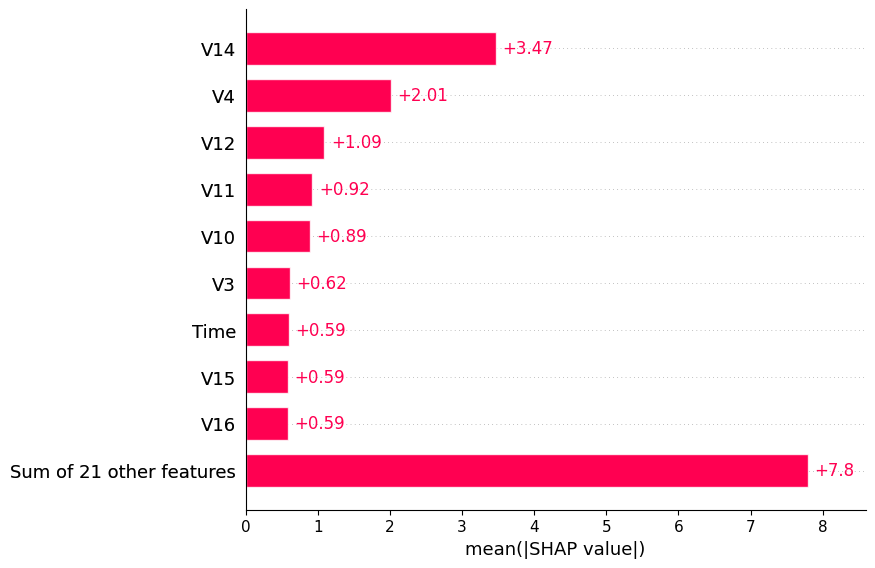

In [60]:
shap.plots.bar(shap_values)

Distribuição dos efeitos:

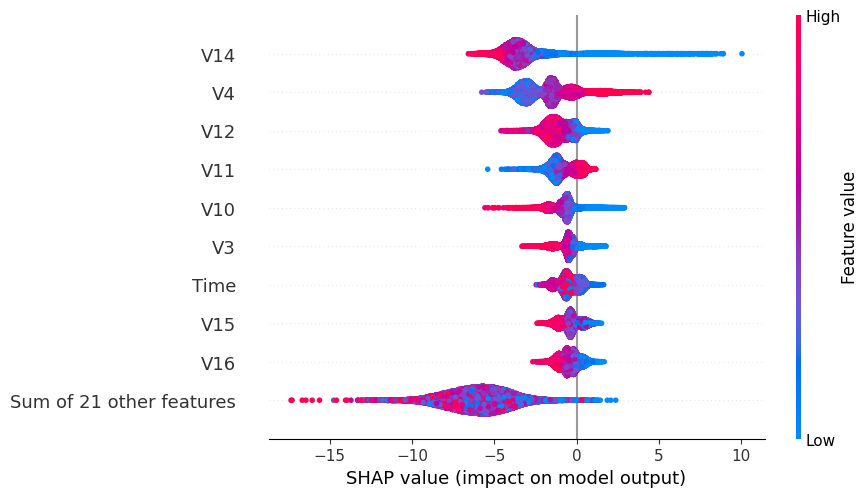

In [61]:
shap.plots.beeswarm(shap_values)


Para explicar uma transação específica:

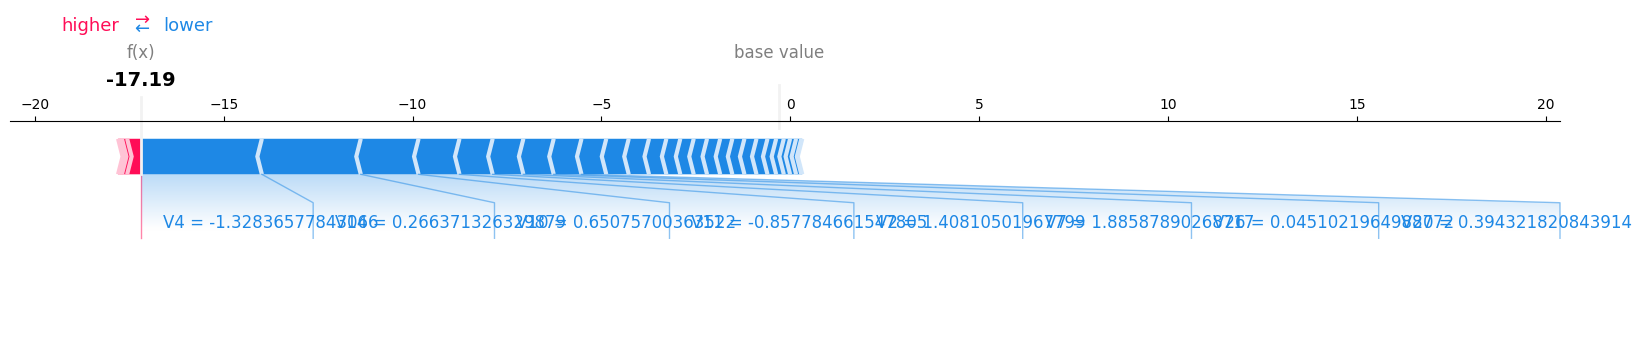

In [62]:
indice = 0

shap.plots.force(
    shap_values[indice],
    matplotlib=True
)




# A diferença entre Precision e Recall neste contexto:

* Recall (Sensibilidade ou Cobertura): O Recall mede a proporção de fraudes reais que o seu modelo conseguiu identificar corretamente. Em outras palavras, de todas as transações que realmente eram fraude, quantas o modelo sinalizou como fraude? Um Recall alto significa que o modelo é bom em 'pegar' a maioria das fraudes.

**Importância na detecção de fraude:** Um Recall baixo para fraudes é perigoso, pois significa que muitas transações fraudulentas estão passando despercebidas, o que pode resultar em grandes perdas financeiras.

* Precisão (Precision): A Precisão mede a proporção de predições de fraude do seu modelo que realmente eram fraude. Em outras palavras, de todas as transações que o modelo classificou como fraude, quantas de fato eram fraudes? Uma Precisão alta significa que, quando o modelo diz que algo é fraude, é muito provável que seja mesmo.

**Importância na detecção de fraude:** Uma Precisão baixa significa que o modelo está gerando muitos 'falsos positivos' (transações normais classificadas como fraude). Isso pode causar inconvenientes para clientes legítimos (ter suas transações bloqueadas, por exemplo) e gerar custos operacionais altos para a equipe que precisa revisar essas 'falsas fraudes'.

Em resumo:

Recall alto: Não deixa muitas fraudes reais passarem.
Precisão alta: Não incomoda muitos clientes legítimos com falsos alertas.

Em problemas de detecção de fraude, geralmente busca-se um equilíbrio, mas muitas vezes dá-se mais peso ao Recall, pois as consequências de uma fraude não detectada podem ser muito mais severas do que as de um falso positivo, desde que a Precisão não seja tão baixa a ponto de tornar o sistema inviável por excesso de alertas.